# Introduction to Regression with Neural Network in TensorFlow

There are many definitions for a regression problem but in our case, we're going to simplify it: predicting a numerical variable based on some other combination of variables, even shorter... predicting a number.

## Typical architecture of a regresison neural network

The word *typical* is on purpose.

Why?

Because there are many different ways (actually, there's almost an infinite number of ways) to write neural networks.

But the following is a generic setup for ingesting a collection of numbers, finding patterns in them and then outputting some kind of target number.

Yes, the previous sentence is vague but we'll see this in action shortly.

| **Hyperparameter** | **Typical value** |
| --- | --- |
| Input layer shape | Same shape as number of features (e.g. 3 for # bedrooms, # bathrooms, # car spaces in housing price prediction) |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited |
| Neurons per hidden layer | Problem specific, generally 10 to 100 |
| Output layer shape | Same shape as desired prediction shape (e.g. 1 for house price) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) |
| Output activation | None, ReLU, logistic/tanh |
| Loss function | [MSE](https://en.wikipedia.org/wiki/Mean_squared_error) (mean square error) or [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) (mean absolute error)/Huber (combination of MAE/MSE) if outliers |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) |

*Table 1: Typical architecture of a regression network. Source: Adapted from page 293 of [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow Book by Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632/)*

Again, if you're new to neural networks and deep learning in general, much of the above table won't make sense. But don't worry, we'll be getting hands-on with all of it soon.

> 🔑 **Note:** A **hyperparameter** in machine learning is something a data analyst or developer can set themselves, where as a **parameter** usually describes something a model learns on its own (a value not explicitly set by an analyst).

Okay, enough talk, let's get started writing code.

To use TensorFlow, we'll import it as the common alias `tf` (short for TensorFlow).

In [2]:
# Import TensorFlow
import tensorflow as tf
print(tf.__version__) # check the version

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

2.10.0
Notebook last run (end-to-end): 2026-09-22 16:18:50.374567


## Creating data to view and fit

since we're working on **regression problem** (predicting a number) let's create some linear data (a straight line) to model.

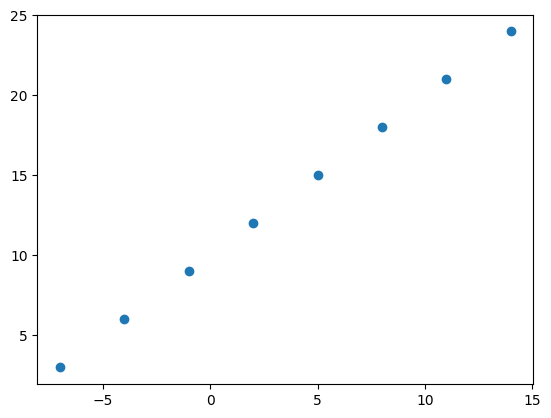

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0]).reshape(-1, 1)

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);

In [4]:
y  == X + 10

array([[ True, False, False, False, False, False, False, False],
       [False,  True, False, False, False, False, False, False],
       [False, False,  True, False, False, False, False, False],
       [False, False, False,  True, False, False, False, False],
       [False, False, False, False,  True, False, False, False],
       [False, False, False, False, False,  True, False, False],
       [False, False, False, False, False, False,  True, False],
       [False, False, False, False, False, False, False,  True]])

Before we do any modelling, can you calculate the pattern between `X` and `y`?

For example, say I asked you, based on this data what the `y` value would be if `X` was 17.0?

Or how about if `X` was -10.0?

This kind of pattern discovery is the essence of what we'll be building neural networks to do for us.

## Regression input  and output shapes

One of the most important concepts when working with neural networks are the input and output shapes.

The **input shape** is the shape of your data that goes into the model.

The **output shape** is the shape of your data you want to come out of you model.
These will differ depending on the problem you're working on.

Neural networks accept numbers and output numbers. These numbers are typically represented as tensors (or arrays).

Before, we created data using NumPy arrays, but we could do the same with tensors.

In [5]:
# Create a demo tensor for our housing price prediction problem
# Example input and output shapes of a regression model
house_info = tf.constant(['bedroom', 'bathroom', 'garage'])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700])>)

In [6]:
house_info.shape

TensorShape([3])

In [7]:
X[0], y[0]

(array([-7.]), 3.0)

In [8]:
X[1], y[1]

(array([-4.]), 6.0)

In [9]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

((1,), ())

In [10]:
X[0].ndim

1

In [11]:
X[0], y[0]

(array([-7.]), 3.0)

In [12]:
# Turn our NumPy arrays into tensor
X = tf.cast(tf.constant(X), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
X, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [13]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([1]), TensorShape([]))

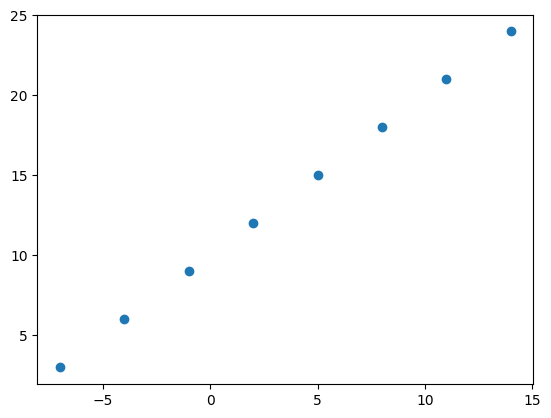

In [14]:
plt.scatter(X, y)

## Steps in modellin with TensorFlow

1. **Creating a model** - define the input and output layers, as well as the hidden layers of a deep learning model.
2. **Compiling a model** - define the loss function (in others words, the function which tells our model how wrong it is) and the optimizer (tells our model how to improve the patterns its learning) and evaluation metricx (what we can use to interpret the performance of our model).
3. **Fitting a model** - letting the model try to find patterns between X & y (features and labels).

In [15]:
# model = tf.keras.Sequential()
# model.add(tf.keras.layers.Dense(1))

In [16]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(
    loss=tf.keras.losses.mae,  # mae is short for mean absolute error
    optimizer=tf.keras.optimizers.SGD(), # sgd is short for stochastic gradient descent
    metrics=['mae']
)

# 3. Fit the model
model.fit(X, y, epochs=5)

Epoch 1/5
1/1 [==============================] - 0s 262ms/step - loss: 14.4728 - mae: 14.4728
Epoch 2/5
1/1 [==============================] - 0s 2ms/step - loss: 14.3403 - mae: 14.3403
Epoch 3/5
1/1 [==============================] - 0s 2ms/step - loss: 14.2078 - mae: 14.2078
Epoch 4/5
1/1 [==============================] - 0s 2ms/step - loss: 14.0753 - mae: 14.0753
Epoch 5/5
1/1 [==============================] - 0s 2ms/step - loss: 13.9428 - mae: 13.9428


In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________


In [18]:
# from tensorflow.keras.utils import plot_model

# plot_model(model, show_shapes=True)

In [19]:
# Check out X and y
X, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [20]:
# Try and make a prediction using our model
y_pred = model.predict([17.0])
y_pred

1/1 [==============================] - 0s 61ms/step


array([[-1.7001796]], dtype=float32)

In [21]:
y_pred + 11

array([[9.29982]], dtype=float32)

## Improving our model

We can improve our model, by altering the steps we took to create a model.

1. **Creatin a model** - here we might add more layers, increase the number of hidden units (also called neurons) within each of the hidden layers, change the activation function of each layer.
2. **Compiling a model** - here we might change the optimization function or perhaps the **learning rate** of the optimization function.
3. **Fitting a model** - here we might fit a model for more **epochs** (leave it training for longer) or on more data (give the model more examples to learn from)

In [22]:
# Let's rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer='sgd',
              metrics=['mae'])

# 3. Fit the model (this time we'll train for longer)
model.fit(X, y, epochs=50, verbose=1)

Epoch 1/50
1/1 [==============================] - 0s 169ms/step - loss: 12.9339 - mae: 12.9339
Epoch 2/50
1/1 [==============================] - 0s 4ms/step - loss: 12.8014 - mae: 12.8014
Epoch 3/50
1/1 [==============================] - 0s 3ms/step - loss: 12.6689 - mae: 12.6689
Epoch 4/50
1/1 [==============================] - 0s 3ms/step - loss: 12.5364 - mae: 12.5364
Epoch 5/50
1/1 [==============================] - 0s 3ms/step - loss: 12.4039 - mae: 12.4039
Epoch 6/50
1/1 [==============================] - 0s 3ms/step - loss: 12.2714 - mae: 12.2714
Epoch 7/50
1/1 [==============================] - 0s 3ms/step - loss: 12.1389 - mae: 12.1389
Epoch 8/50
1/1 [==============================] - 0s 3ms/step - loss: 12.0064 - mae: 12.0064
Epoch 9/50
1/1 [==============================] - 0s 3ms/step - loss: 11.8739 - mae: 11.8739
Epoch 10/50
1/1 [==============================] - 0s 4ms/step - loss: 11.7414 - mae: 11.7414
Epoch 11/50
1/1 [==============================] - 0s 3ms/step - lo

In [23]:
# Remind ourselves of the data
X, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [24]:
# Let's see if our model's prediction has improved..
model.predict([17.0])

1/1 [==============================] - 0s 53ms/step


array([[29.414555]], dtype=float32)

In [25]:
# Let's see if we can make another to improve our model

# 1. Create the model (this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation=None),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(
    loss='mae',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics='mae'
)

# 3. Fit the model
model.fit(X, y, epochs=100)

Epoch 1/100
1/1 [==============================] - 0s 222ms/step - loss: 12.9935 - mae: 12.9935
Epoch 2/100
1/1 [==============================] - 0s 3ms/step - loss: 11.9638 - mae: 11.9638
Epoch 3/100
1/1 [==============================] - 0s 2ms/step - loss: 10.9253 - mae: 10.9253
Epoch 4/100
1/1 [==============================] - 0s 3ms/step - loss: 9.8736 - mae: 9.8736
Epoch 5/100
1/1 [==============================] - 0s 2ms/step - loss: 8.8026 - mae: 8.8026
Epoch 6/100
1/1 [==============================] - 0s 3ms/step - loss: 7.7061 - mae: 7.7061
Epoch 7/100
1/1 [==============================] - 0s 2ms/step - loss: 6.8496 - mae: 6.8496
Epoch 8/100
1/1 [==============================] - 0s 3ms/step - loss: 7.1732 - mae: 7.1732
Epoch 9/100
1/1 [==============================] - 0s 3ms/step - loss: 7.6029 - mae: 7.6029
Epoch 10/100
1/1 [==============================] - 0s 3ms/step - loss: 7.7927 - mae: 7.7927
Epoch 11/100
1/1 [==============================] - 0s 3ms/step - loss:

In [26]:
# Let's remind ourselves of the data
X, y

(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [27]:
# Let's try to make a prediction
model.predict([17.0])

1/1 [==============================] - 0s 48ms/step


array([[26.953638]], dtype=float32)

### Evaluating a model

In practice, a typical workflo you'll go thrugh when building neural network is:

> Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it...


When it comes to evaluation... there are 3 words you should memorize:
> "Visualize, Visualize, visualize"

It's a good idea to visualize:
* The data - what data are we working with? What does it look like?
* The model itself - what does our model look like?
* The training of a model - how does a model perform while it learns?
* The predictions of the model - how do the predictions of a model line up against the gorund truth (the original labels)?

In [28]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])>

In [29]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

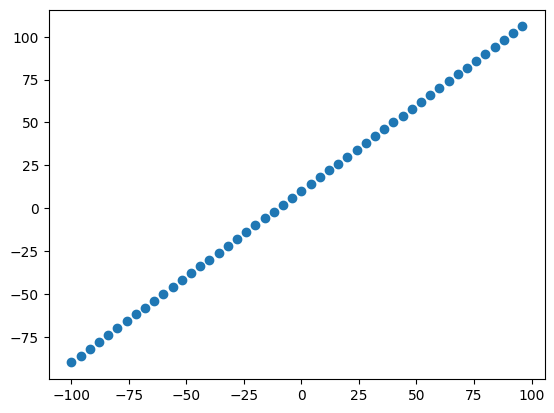

In [30]:
# Visualize the data
import matplotlib.pyplot as ply

plt.scatter(X, y)

### The 3 sets...

* **Training set** - the model learns from this data, which is typically 0-80% of the total data you have available.
* **Validation set** - the model gets tuned on this data, which is typically 10-15% of the data available.
* **Test set** - the model gets evaluated on this data to test what is has learned, this set is typically 10-15% of the total data availabe.

In [31]:
# Check the length of how many samples we have
len(X)

50

In [32]:
# Split the data into train and tes sets
X_train = X[:40] # first 40 are training samples (80% of the data)
y_train = y[:40]

X_test = X [40:] # last 10 are testing samples (20% of the data)
y_test = y[40:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

### Visualising the data

Now we've got our data in training and test sets... let's visualize it again!

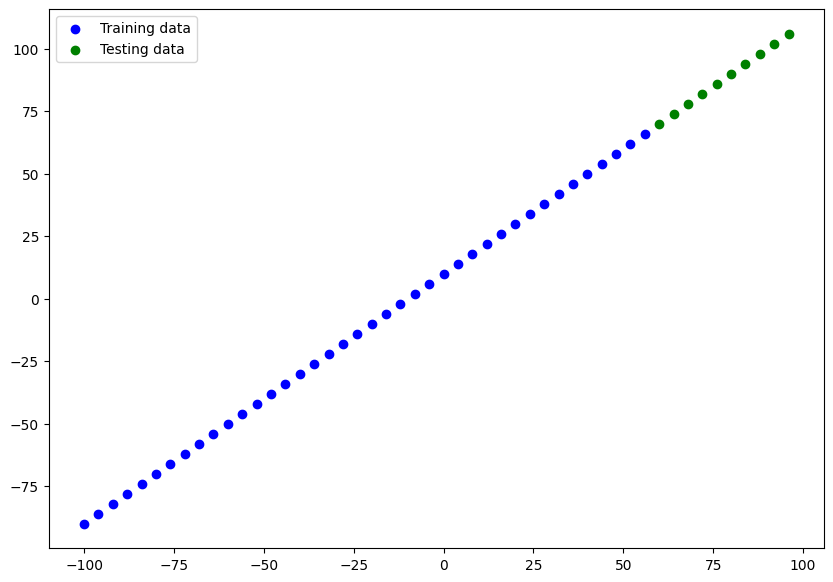

In [33]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c='b', label='Training data')
# Plot test data in green
plt.scatter(X_test, y_test, c='g', label="Testing data")
# Show a legend
plt.legend()
plt.show()

In [34]:
# Let's have a look at how to build a neural network for our data

# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

# 3. Fit the model
# model.fit(X_train, y_train, epochs=100)

### Visualizing the model

In [35]:
# Intentionally error due to input shape is not defined

# model.summary()

In [36]:
X_train.shape, X[0], y[0]

(TensorShape([40]),
 <tf.Tensor: shape=(), dtype=int32, numpy=-100>,
 <tf.Tensor: shape=(), dtype=int32, numpy=-90>)

In [37]:
# Let's create a model which builds automatically by defining the input_shape argument in the first layer
tf.random.set_seed(42)

# 1. Create a model same as above
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name='input_layer'),
    tf.keras.layers.Dense(1, name='output_layer')
], name="model_1")

# 2. Compile the model
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics='mae'
)

In [38]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (Dense)         (None, 10)                20        
                                                                 
 output_layer (Dense)        (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


* **Total params** - total number of parameters in the model.
* **Trainable params** - these are the parameters (patterns) the model can update as it trains.
* **Non-trainable params** - these parameters arent' updated during training (this is typical when you bring in already learn patterns or parameters from other models during **transfer learning**)

📖 **Resource:** For a more in-depth overview of the trainable parameters within a layer, check out [MIT's introduction to deep learning video](https://youtu.be/njKP3FqW3Sk). 

🛠 **Exercise:** Try playing around with the number of hidden units in the dense layer, see how that effects the number of parameters (total and trainable) by calling `model.summary()`.

## How Parameters Work in a Neural Network

Think of your model as a tiny machine that learns this formula:

**y = weight × X + bias**

Your data is `y = X + 10`, so the model needs to figure out that weight = 1 and bias = 10.

---

### Input Shape = 1

This just means you're feeding the model **one number at a time**. Your X is just a list of single numbers (-100, -96, -92, ..., 96). If you had something like (age, height, weight) as input, the input shape would be 3.

---

### Parameters = the numbers the model learns

Your single Dense layer has:
- **1 weight** (the multiplier for X)
- **1 bias** (the number added at the end)

That's it. Just 2 numbers.

---

- **Total params (2)** → all the numbers stored in the model (weight + bias = 2)
- **Trainable params (2)** → how many of those numbers the model is *allowed to change* during training. Here, both can change, so it's also 2.
- **Non-trainable params (0)** → numbers that are *frozen* and can't change. You'd only see this if you locked some layers on purpose (like in transfer learning). You have none frozen, so it's 0.

---

So in short: your model is just learning two numbers (weight and bias) to fit the line `y = X + 10`. That's why everything is 2.

In [39]:
# Let's fit our model to the training data 
model.fit(X_train, y_train, epochs=100, verbose=0)

In [40]:
# Get a summary of our model
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (Dense)         (None, 10)                20        
                                                                 
 output_layer (Dense)        (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


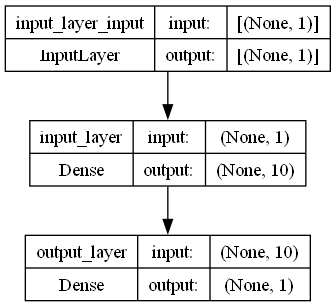

In [41]:
from tensorflow.keras.utils import plot_model

import os
os.makedirs('01_neural_network_diagram', exist_ok=True)

plot_model(model, show_shapes=True, to_file='01_neural_network_diagram/model_1.png')

### Visualizing our model predictions

To visualize predictions, it's a good idea to plot them against the gorund truth labels.

Often you'll see this in the from of `y_test` or `y_true` versus `y_pred` (ground truth versus you model's prediction)

In [42]:
# Make some prediction
y_pred = model.predict(X_test)
y_pred

1/1 [==============================] - 0s 38ms/step


array([[ 69.357704],
       [ 73.32143 ],
       [ 77.285164],
       [ 81.24889 ],
       [ 85.212616],
       [ 89.176346],
       [ 93.14009 ],
       [ 97.10381 ],
       [101.06754 ],
       [105.03126 ]], dtype=float32)

In [43]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

🔑 **Note:** If you feel like you're going to reuse some kind of functionality in the future, it's a good idea to turn it into function

In [44]:
# Let's create a plottinf fucntion
def plot_prediction(train_data=X_train, 
                    train_labels=y_train,
                    test_data=X_test, 
                    test_labels=y_test,
                    predictions=y_pred):
    """
    Plots training data, test data and compare preictions to ground truth labels.
    """

    plt.figure(figsize=(10, 7))
    # Plot training data in blue
    plt.scatter(train_data, train_labels, c='b', label='Training data')
    # Plot testing data in green
    plt.scatter(test_data, test_labels, c='g', label='Testing data')
    # Plot models prediction in red
    plt.scatter(test_data, predictions, c='r', label='Prediction data')
    # Show the legend
    plt.legend()
    plt.show()


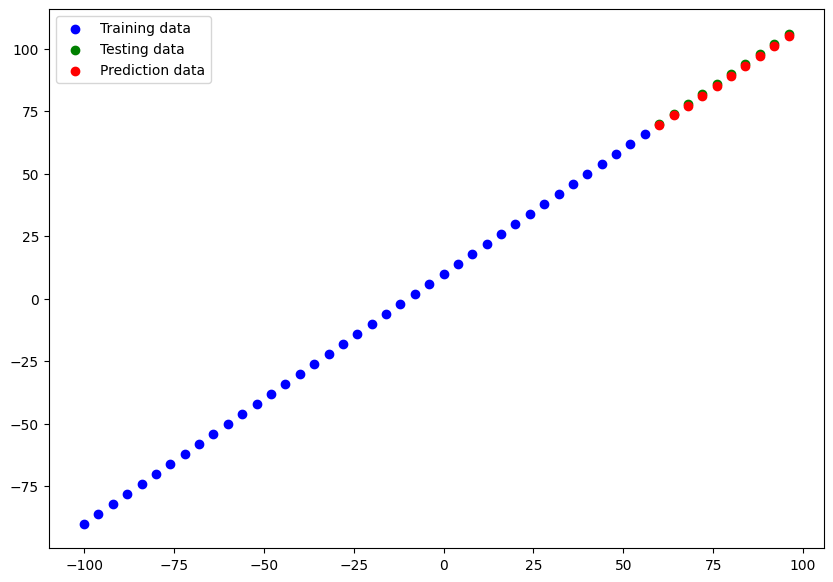

In [45]:
plot_prediction(train_data=X_train, 
                train_labels=y_train,
                test_data=X_test,
                test_labels=y_test,
                predictions=y_pred)

### Evaluation our model's prediction with regression evaluation metrics

Depending on the problem you're working on, there will different evaluation metrics to evaluate your model's performance

Since we're working on a regression, two of th emain metrics:
* MAE - mean absolute error, "on average, how wrong is each of my model's predictions.
* MSE - mean square error, "Square the average errors"

In [46]:
# Evaluate the model on the test set
model.evaluate(X_test, y_test)

1/1 [==============================] - 0s 87ms/step - loss: 0.8055 - mae: 0.8055


[0.8055092096328735, 0.8055092096328735]

In [47]:
# Calculate the mean absolute error
# The wrong version due to different shape of y_true and y_pred
mae = tf.metrics.mean_absolute_error(y_true=y_test, y_pred=tf.constant(y_pred))
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([18.642296, 15.342859, 12.828901, 11.100443, 10.157476, 10.      ,
       10.628018, 12.041525, 14.240526, 17.225006], dtype=float32)>

In [48]:
tf.constant(y_pred)

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[ 69.357704],
       [ 73.32143 ],
       [ 77.285164],
       [ 81.24889 ],
       [ 85.212616],
       [ 89.176346],
       [ 93.14009 ],
       [ 97.10381 ],
       [101.06754 ],
       [105.03126 ]], dtype=float32)>

In [49]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

In [50]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 69.357704,  73.32143 ,  77.285164,  81.24889 ,  85.212616,
        89.176346,  93.14009 ,  97.10381 , 101.06754 , 105.03126 ],
      dtype=float32)>

In [51]:
# Calculate the mean absolute error
mae = tf.metrics.mean_absolute_error(y_true=y_test,
                                     y_pred=tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=0.8055145>

In [52]:
# Calculate the mean square error
mse = tf.metrics.mean_squared_error(
    y_true=y_test, y_pred=tf.squeeze(y_pred)
)
mse

<tf.Tensor: shape=(), dtype=float32, numpy=0.65970695>

In [53]:
# Make some function to reuse MAE and MSE
def mae(y_true, y_pred):
    return tf.metrics.mean_absolute_error(
        y_true=y_true, y_pred=tf.squeeze(y_pred)
)

def mse(y_true, y_pred):
    return tf.metrics.mean_squared_error(
        y_true=y_true, y_pred=tf.squeeze(y_pred)
)

### Running experiments to improve our model

> Build a model -> fit it -> evaluate it -> tweak it -> fit it -> evaluate it -> tweak it -> fit it -> evaluate it

1. Get more data - get more examples for your model to train on (more opportunities to learn patterns or relationships between features and labels).
2. Make you model larger (using a more complex model) - this might come in the form of more layers or more hidden units in each layer.
3. Train for longer - give your model more of a change to find patterns in the data.

Let's do 3 modelling experiments:

1. `model_1` - same as the original model, 1 layer, trained for 100 epochs.
2. `model_2` - 2 layers, trained for 100 epochs
3. `model_3` - 2 layers, trained for 500 epochs
4. 
5. 

**Build `model_1`**

In [54]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

# 2. Compile the model
model_1.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mae']
)

# 3. Fit the model
model_1.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 [==============================] - 0s 1000us/step - loss: 20.8948 - mae: 20.8948
Epoch 2/100
2/2 [==============================] - 0s 2ms/step - loss: 9.4257 - mae: 9.4257
Epoch 3/100
2/2 [==============================] - 0s 2ms/step - loss: 7.6235 - mae: 7.6235
Epoch 4/100
2/2 [==============================] - 0s 2ms/step - loss: 9.9752 - mae: 9.9752
Epoch 5/100
2/2 [==============================] - 0s 2ms/step - loss: 10.9471 - mae: 10.9471
Epoch 6/100
2/2 [==============================] - 0s 1000us/step - loss: 10.1158 - mae: 10.1158
Epoch 7/100
2/2 [==============================] - 0s 1000us/step - loss: 9.1432 - mae: 9.1432
Epoch 8/100
2/2 [==============================] - 0s 1ms/step - loss: 9.1084 - mae: 9.1084
Epoch 9/100
2/2 [==============================] - 0s 1ms/step - loss: 15.1433 - mae: 15.1433
Epoch 10/100
2/2 [==============================] - 0s 2ms/step - loss: 7.5627 - mae: 7.5627
Epoch 11/100
2/2 [==============================] - 0s 1ms/ste

1/1 [==============================] - 0s 63ms/step


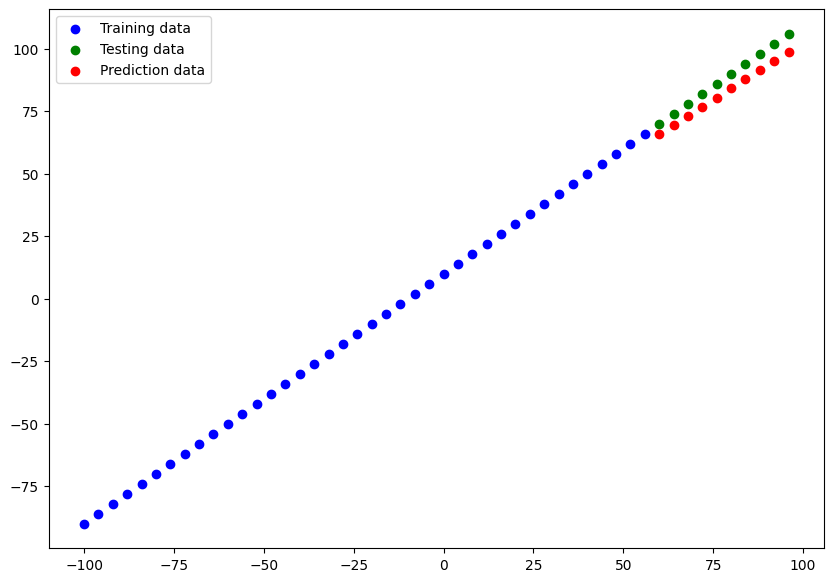

In [55]:
# Make and plot prediction for model_1
y_preds_1 = model_1.predict(y_test)
plot_prediction(predictions=y_preds_1)

In [56]:
# Calculate model_1 evaluation metric
mae_1 = mae(y_test, y_preds_1)
mse_1 = mse(y_test, y_preds_1)
mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=5.670961>,
 <tf.Tensor: shape=(), dtype=float32, numpy=32.988556>)

**Build `model_2`**

* 2 dense layers, trained for 100 epochs

In [57]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mse']
)

# 3. Fit the model
model_2.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 [==============================] - 0s 2ms/step - loss: 65.6487 - mse: 6490.1450
Epoch 2/100
2/2 [==============================] - 0s 3ms/step - loss: 22.6149 - mse: 801.5778
Epoch 3/100
2/2 [==============================] - 0s 2ms/step - loss: 17.9375 - mse: 467.6107
Epoch 4/100
2/2 [==============================] - 0s 2ms/step - loss: 13.1862 - mse: 229.6898
Epoch 5/100
2/2 [==============================] - 0s 1ms/step - loss: 14.5353 - mse: 261.1972
Epoch 6/100
2/2 [==============================] - 0s 2ms/step - loss: 11.5961 - mse: 155.0941
Epoch 7/100
2/2 [==============================] - 0s 2ms/step - loss: 12.6498 - mse: 214.1107
Epoch 8/100
2/2 [==============================] - 0s 1ms/step - loss: 11.0403 - mse: 150.3265
Epoch 9/100
2/2 [==============================] - 0s 3ms/step - loss: 39.6295 - mse: 2460.5908
Epoch 10/100
2/2 [==============================] - 0s 1ms/step - loss: 27.1290 - mse: 1035.4642
Epoch 11/100
2/2 [============================

1/1 [==============================] - 0s 37ms/step


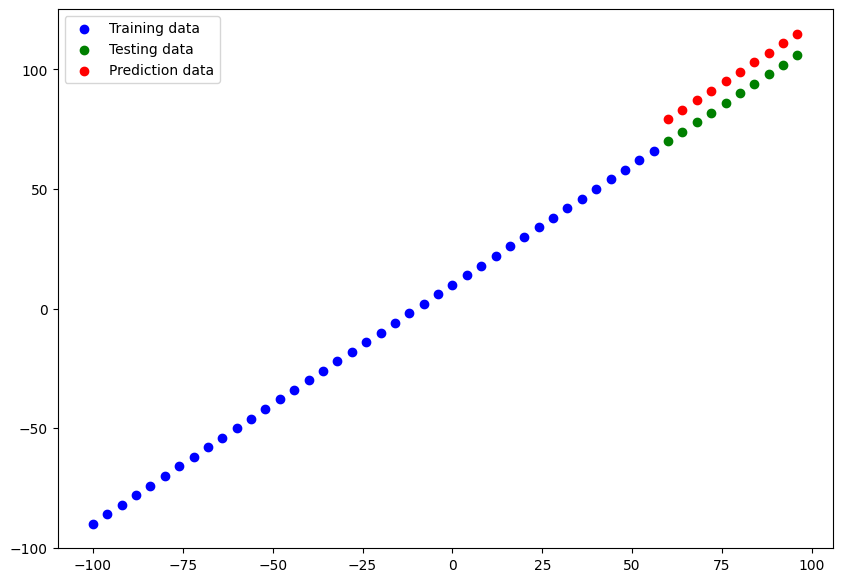

In [58]:
# Make and plot predictions for model_2
y_preds_2 = model.predict(y_test)
plot_prediction(predictions=y_preds_2)

In [59]:
mae_2 = mae(y_test, y_preds_2)
mse_2 = mse(y_test, y_preds_2)

mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=9.103815>,
 <tf.Tensor: shape=(), dtype=float32, numpy=82.8903>)

** Build `models_3`**

* 2 layers, trained for 500 epochs

In [60]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1]),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mae']
)

# 3. Fit the mode
model_3.fit(X_train, y_train, epochs=500)

Epoch 1/500
2/2 [==============================] - 0s 2ms/step - loss: 36.7047 - mae: 36.7047
Epoch 2/500
2/2 [==============================] - 0s 1000us/step - loss: 29.0229 - mae: 29.0229
Epoch 3/500
2/2 [==============================] - 0s 2ms/step - loss: 33.0536 - mae: 33.0536
Epoch 4/500
2/2 [==============================] - 0s 2ms/step - loss: 13.4070 - mae: 13.4070
Epoch 5/500
2/2 [==============================] - 0s 2ms/step - loss: 18.1535 - mae: 18.1535
Epoch 6/500
2/2 [==============================] - 0s 2ms/step - loss: 8.0257 - mae: 8.0257
Epoch 7/500
2/2 [==============================] - 0s 2ms/step - loss: 12.8865 - mae: 12.8865
Epoch 8/500
2/2 [==============================] - 0s 2ms/step - loss: 11.1676 - mae: 11.1676
Epoch 9/500
2/2 [==============================] - 0s 1ms/step - loss: 41.0847 - mae: 41.0847
Epoch 10/500
2/2 [==============================] - 0s 998us/step - loss: 28.4043 - mae: 28.4043
Epoch 11/500
2/2 [==============================] - 0s 2

1/1 [==============================] - 0s 30ms/step


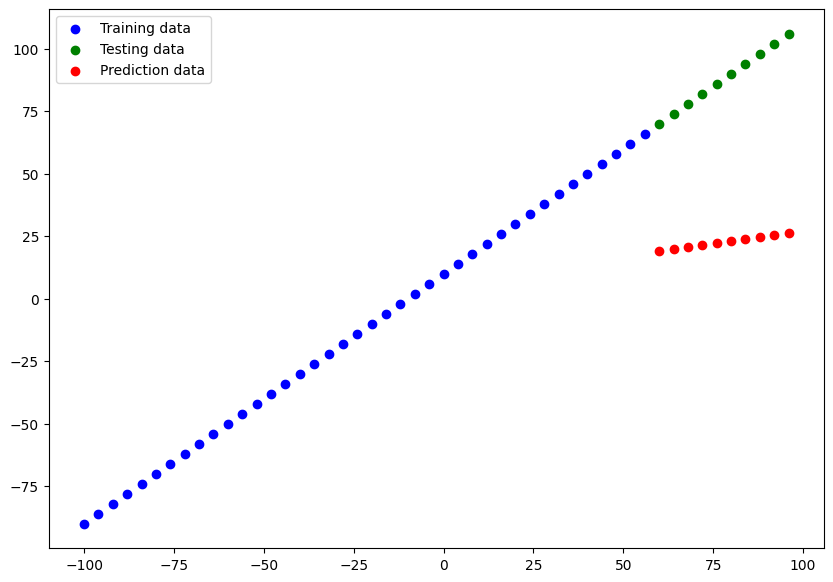

In [61]:
# Make a plot some predictions
y_preds_3 = model_3.predict(y_test)
plot_prediction(predictions=y_preds_3)

In [62]:

# Calculate model 3 evaluation metrics
mae_3 = mae(y_test, y_preds_3)
mse_3 = mse(y_test, y_preds_3)

mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=65.277756>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4344.0977>)

🔑 **Note:** You want to start with small experiments (small mdoels) and make sure they work and then increase their scale when necessary.

### Comparing the results of our experiments

We've run few experiments, let's compare the results.

In [63]:
# Let's compare our model's results using a pandas DataFrame
import pandas as pd

model_results = [
    ['model_1', mae_1.numpy(), mse_2.numpy()],
    ['model_2', mae_2.numpy(), mse_2.numpy()],
    ['model_3', mae_3.numpy(), mse_3.numpy()]
]
all_results = pd.DataFrame(model_results, columns=['model', 'mae', 'mse'])

all_results

,model,mae,mse
0,model_1,5.670961,82.890297
1,model_2,9.103815,82.890297
2,model_3,65.277756,4344.097656


Looks like `model_2` performed the best...

In [64]:
model_2.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                20        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


> 🔑 **Note:** One of your main goals should be to minimize the time between your experiments. The more experiments you do, the morething you'll figure out which don't work and in turn, get coler to figuring out what does work. Remember the machine learning practitioner's motto: "experiment, experiment, experiment.

## Tracking your experiments

One really good habit in machine learning modelling is to track the result of your experiments

And when doing so, it can be tedious if you're running lost of experiments.

Luckily, there are tools to thelp us!

📖 **Resource:** As you build more models, you'll want to look into using:

* TensorBoard - a component of the TensorFlow library to help track modelling experiments (we'll see this one later).
* Weight & Biases - a tool for tracking all of kinds of machine learning experiments (plugs straight into TensorBoard)

## Saving our models

Saving our models allows us to use them outside of Google Colab (or wherever they were trained) such as in web application or a mobile app

There are two main formats we can save our model's too:
1. The SavedModel format
2. The HDF5 format

In [65]:
# Save model using the SavedModel format
model_2.save('best_model_SavedModel_format')

INFO:tensorflow:Assets written to: best_model_SavedModel_format\assets


In [66]:
# Save model using HDF5 format
model_2.save('best_model_HDF5_format.h5')

## Loading in a saved Model

In [67]:
# Load in the SavedModel format
loaded_SavedModel_format = tf.keras.models.load_model('best_model_SavedModel_format')

loaded_SavedModel_format.summary()


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                20        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


In [68]:
# Compare the model_2 predictions with SavedModel format model predictions
model_2_preds = model_2.predict(X_test)

loaded_SavedModel_format_preds = loaded_SavedModel_format.predict(X_test)

model_2_preds == loaded_SavedModel_format_preds

1/1 [==============================] - 0s 29ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [69]:
# Compare the MAE of model_2_preds and loaded_Saved_model_preds
mae(y_true=y_test, y_pred=model_2_preds) == mae(y_true=y_test, y_pred=loaded_SavedModel_format_preds)

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [70]:
# Load in a model using the HDF5 format
loaded_h5_model = tf.keras.models.load_model('best_model_HDF5_format.h5')

loaded_h5_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                20        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


In [71]:
model_2.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                20        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31
Trainable params: 31
Non-trainable params: 0
_________________________________________________________________


In [72]:
# Check to see if loaded .h5 model predictions match model_2
model_2_preds = model_2.predict(X_test)

loaded_h5_model_preds = loaded_h5_model.predict(X_test)

model_2_preds == loaded_h5_model_preds

1/1 [==============================] - 0s 30ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

## Donwload a model (or any other file) from Google Colab

If you want to download your files from Google Colab:

1. You can go to the 'files' tab and right click on the file you're after and click download

2. Use code (see the cell below).
3. Save it to Google Drive by connecting Google Drive and copying it there (see 2nd code cell below).

In [73]:
# # Download a file from Google Colab
# from google.colab import files
# files.dowload('/content/best_model_HDF5_format.h5')

In [74]:
# # Save a file from Google Colab to Google Drive (requires mounting Google Drive)
# !cp /content/best_model_HDF5_format.h5 /content/drive/MyDrive/tensorflow


## A larger example

In [75]:
# Import required libraries
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [76]:
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [77]:
# Let's try one-hot encode our DataFrame so it's all numbers
insurance_one_hot = pd.get_dummies(insurance).astype(int)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,1,0,0,1,0,0,0,1
1,18,33,1,1725,0,1,1,0,0,0,1,0
2,28,33,3,4449,0,1,1,0,0,0,1,0
3,33,22,0,21984,0,1,1,0,0,1,0,0
4,32,28,0,3866,0,1,1,0,0,1,0,0


In [78]:
# Create X & y valeus (feature and labels)
X = insurance_one_hot.drop('charges', axis=1)
y = insurance_one_hot['charges']

In [79]:
# View X
X.head(3)

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27,0,1,0,0,1,0,0,0,1
1,18,33,1,0,1,1,0,0,0,1,0
2,28,33,3,0,1,1,0,0,0,1,0


In [80]:
# View y
y.head()

0    16884
1     1725
2     4449
3    21984
4     3866
Name: charges, dtype: int32

In [81]:
# Create training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X), len(X_train), len(X_test)

(1338, 1070, 268)

In [82]:
X_train.head(1)

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,46,19,2,1,0,1,0,0,1,0,0


In [83]:
X_train.shape[1]

11

In [84]:
# Build a neural network (sort of like model_2 above)
tf.random.set_seed(42)

# 1. Create a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[X_train.shape[1]]),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mae']
)

# 3. Fit the model
insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 [==============================] - 0s 545us/step - loss: 8706.0449 - mae: 8706.0449
Epoch 2/100
34/34 [==============================] - 0s 545us/step - loss: 7860.4385 - mae: 7860.4385
Epoch 3/100
34/34 [==============================] - 0s 515us/step - loss: 7576.9062 - mae: 7576.9062
Epoch 4/100
34/34 [==============================] - 0s 546us/step - loss: 7663.0537 - mae: 7663.0537
Epoch 5/100
34/34 [==============================] - 0s 531us/step - loss: 7639.8433 - mae: 7639.8433
Epoch 6/100
34/34 [==============================] - 0s 576us/step - loss: 7639.4634 - mae: 7639.4634
Epoch 7/100
34/34 [==============================] - 0s 545us/step - loss: 7526.4282 - mae: 7526.4282
Epoch 8/100
34/34 [==============================] - 0s 606us/step - loss: 7773.5181 - mae: 7773.5181
Epoch 9/100
34/34 [==============================] - 0s 606us/step - loss: 7535.8887 - mae: 7535.8887
Epoch 10/100
34/34 [==============================] - 0s 515us/step - loss: 7680.0

In [85]:
# Check the results of the insurance model on the test data
insurance_model.evaluate(X_test, y_test)

9/9 [==============================] - 0s 875us/step - loss: 8729.5107 - mae: 8729.5107


[8729.5107421875, 8729.5107421875]

In [86]:
y_train.median(), y_train.mean()

(9574.5, 13345.596261682243)

Right now it looks like ourmodel isn't performing too well... let's try and improve it!

To (try) improve our model, we'll run 2 experiments:
1. Add an extra layer with more hidden units and use the Adam optimizer
2. Same as above but train for longer (200 epochs)
3. Change the optimizer

In [87]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model 
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, input_shape=[X_train.shape[1]]),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)

# 3. Fit the model
insurance_model_2.fit(X_train, y_train, epochs=100, verbose=1)

Epoch 1/100
34/34 [==============================] - 0s 606us/step - loss: 13317.9287 - mae: 13317.9287
Epoch 2/100
34/34 [==============================] - 0s 606us/step - loss: 13215.1621 - mae: 13215.1621
Epoch 3/100
34/34 [==============================] - 0s 636us/step - loss: 12975.1631 - mae: 12975.1631
Epoch 4/100
34/34 [==============================] - 0s 615us/step - loss: 12461.1934 - mae: 12461.1934
Epoch 5/100
34/34 [==============================] - 0s 606us/step - loss: 11527.8467 - mae: 11527.8467
Epoch 6/100
34/34 [==============================] - 0s 606us/step - loss: 10162.7441 - mae: 10162.7441
Epoch 7/100
34/34 [==============================] - 0s 672us/step - loss: 8692.6768 - mae: 8692.6768
Epoch 8/100
34/34 [==============================] - 0s 606us/step - loss: 7702.5010 - mae: 7702.5010
Epoch 9/100
34/34 [==============================] - 0s 652us/step - loss: 7452.6060 - mae: 7452.6060
Epoch 10/100
34/34 [==============================] - 0s 667us/step - 

In [88]:
# Evaluate the larger model
insurance_model_2.evaluate(X_test, y_test)

9/9 [==============================] - 0s 749us/step - loss: 5190.8301 - mae: 5190.8301


[5190.830078125, 5190.830078125]

In [89]:
insurance_model.evaluate(X_test, y_test)

9/9 [==============================] - 0s 625us/step - loss: 8729.5107 - mae: 8729.5107


[8729.5107421875, 8729.5107421875]

In [90]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, input_shape=[X_train.shape[1]]),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_3.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)

# 3. Fit the model
history = insurance_model_3.fit(X_train, y_train, epochs=200)

Epoch 1/200
34/34 [==============================] - 0s 636us/step - loss: 13318.3682 - mae: 13318.3682
Epoch 2/200
34/34 [==============================] - 0s 606us/step - loss: 13172.0693 - mae: 13172.0693
Epoch 3/200
34/34 [==============================] - 0s 592us/step - loss: 12869.0117 - mae: 12869.0117
Epoch 4/200
34/34 [==============================] - 0s 607us/step - loss: 12262.7588 - mae: 12262.7588
Epoch 5/200
34/34 [==============================] - 0s 636us/step - loss: 11203.7998 - mae: 11203.7998
Epoch 6/200
34/34 [==============================] - 0s 606us/step - loss: 9749.5146 - mae: 9749.5146
Epoch 7/200
34/34 [==============================] - 0s 570us/step - loss: 8324.0195 - mae: 8324.0195
Epoch 8/200
34/34 [==============================] - 0s 613us/step - loss: 7562.3774 - mae: 7562.3774
Epoch 9/200
34/34 [==============================] - 0s 587us/step - loss: 7419.2690 - mae: 7419.2690
Epoch 10/200
34/34 [==============================] - 0s 606us/step - lo

In [91]:
# Evaluate our third model
insurance_model_3.evaluate(X_test, y_test)

9/9 [==============================] - 0s 750us/step - loss: 3488.9299 - mae: 3488.9299


[3488.929931640625, 3488.929931640625]

Text(0.5, 0, 'epochs')

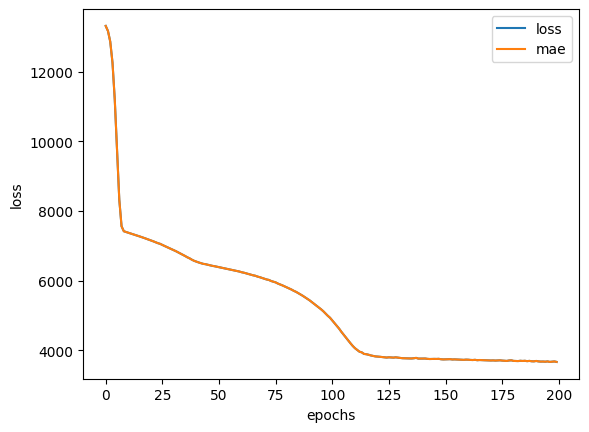

In [92]:
# Plot history (also know as a loss cuver or a training curve)
pd.DataFrame(history.history).plot()
plt.ylabel('loss')
plt.xlabel('epochs')

> 🤔 **Question:** How long should you train for?

It depends. Really... it depens on the problem you're working on. However, many people have asked this question before... so so TensorFlow has a solution It's called the [EarlyStopping Callback](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping), which is a TensorFlow component you can add to your model to stop training once it stops improvin a certain metric.

## Preprocessing data (normalization and standardization)

In terms of scaling values, neural networks tend to prefer normalization.

If you're not sure on which to use, you could try both and see which performs better

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Read in the insurance dataframe
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
insurance.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


To prepare our data, we can borrow a few classes from Scikit-learn.

In [94]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Create a column transformer
ct = make_column_transformer(
    (MinMaxScaler(), ['age', 'bmi', 'children']), # turn all value in these columns between 0 and 1
    (OneHotEncoder(handle_unknown='ignore'), ['sex', 'smoker', 'region'])
)

# Create X & y
X = insurance.drop('charges', axis=1)
y = insurance['charges']

# Build our train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the column transformer to our training data
ct.fit(X_train)

# Transform training and test data with normalisation (MinMaxScaler) and OneHotEncoder
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [95]:
# What does ourdata look like now?
X_train.loc[0]

age                19
sex            female
bmi              27.9
children            0
smoker            yes
region      southwest
Name: 0, dtype: object

In [96]:
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [97]:
X_train.shape, X_train_normal.shape

((1070, 6), (1070, 11))

Beautiful! Our data has been normalized and one hot encoded.
Now let's build a neural network model on it and see how it goes.

In [98]:
# Build a neural network model to fit on our normalized data
tf.random.set_seed(42)

# 1. Create the model
insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_4.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)

# 3. Fit the model
insurance_model_4.fit(X_train_normal, y_train, epochs=100)

Epoch 1/100
34/34 [==============================] - 0s 636us/step - loss: 13343.2520 - mae: 13343.2520
Epoch 2/100
34/34 [==============================] - 0s 606us/step - loss: 13333.1797 - mae: 13333.1797
Epoch 3/100
34/34 [==============================] - 0s 576us/step - loss: 13309.8369 - mae: 13309.8369
Epoch 4/100
34/34 [==============================] - 0s 955us/step - loss: 13262.8525 - mae: 13262.8525
Epoch 5/100
34/34 [==============================] - 0s 956us/step - loss: 13181.2021 - mae: 13181.2021
Epoch 6/100
34/34 [==============================] - 0s 606us/step - loss: 13053.5371 - mae: 13053.5371
Epoch 7/100
34/34 [==============================] - 0s 606us/step - loss: 12869.1475 - mae: 12869.1475
Epoch 8/100
34/34 [==============================] - 0s 606us/step - loss: 12617.5361 - mae: 12617.5361
Epoch 9/100
34/34 [==============================] - 0s 591us/step - loss: 12288.5498 - mae: 12288.5498
Epoch 10/100
34/34 [==============================] - 0s 576us/s

In [99]:
# Evaluate our insuranc emodel trained on normalized data
insurance_model_4.evaluate(X_test_normal, y_test)

9/9 [==============================] - 0s 750us/step - loss: 3437.3657 - mae: 3437.3657


[3437.36572265625, 3437.36572265625]

In [100]:
# Insurance model 2 results
# 9/9 [==============================] - 0s 749us/step - loss: 4686.3706 - mae: 4686.3706


## 🛠 Exercises

We've a covered a whole lot pretty quickly.

So now it's time to have a **play around** with a few things and start to build up your intuition.

I emphasise the words play around because that's very important. Try a few things out, run the code and see what happens.

1. Create your own regression dataset (or make the one we created in "Create data to view and fit" bigger) and build fit a model to it.
2. Try building a neural network with 4 Dense layers and fitting it to your own regression dataset, how does it perform?
3. Try and improve the results we got on the insurance dataset, some things you might want to try include:
  * Building a larger model (how does one with 4 dense layers go?).
  * Increasing the number of units in each layer.
  * Lookup the documentation of [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) and find out what the first parameter is, what happens if you increase it by 10x?
  * What happens if you train for longer (say 300 epochs instead of 200)? 
4. Import the [Boston pricing dataset](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/boston_housing/load_data) from TensorFlow [`tf.keras.datasets`](https://www.tensorflow.org/api_docs/python/tf/keras/datasets) and model it.


### 1. Create your own regression dataset (or make the one we created in "Create data to view and fit" bigger) and build fit a model to it

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=1000, n_features=10, n_targets=1)

X.shape, y.shape

((1000, 10), (1000,))

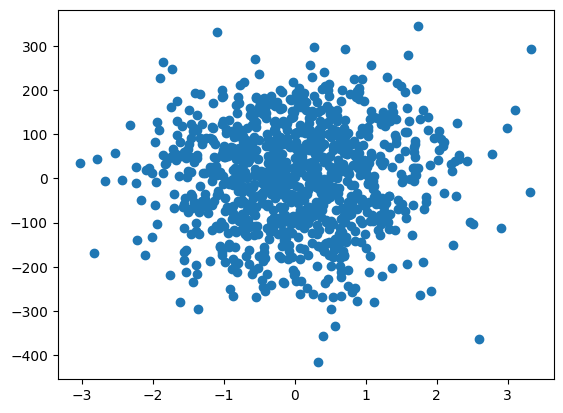

In [113]:
# Let's visualzie the dataset
plt.scatter(X[:, 0], y)

In [114]:
# Modelling our dummy data

# Set the random seed
tf.random.set_seed(42)

# Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics='mae')

# Fitting the model
model.fit(X, y, epochs=10)

Epoch 1/10
32/32 [==============================] - 0s 581us/step - loss: 94.9620 - mae: 94.9620
Epoch 2/10
32/32 [==============================] - 0s 694us/step - loss: 94.9097 - mae: 94.9097
Epoch 3/10
32/32 [==============================] - 0s 581us/step - loss: 94.8575 - mae: 94.8575
Epoch 4/10
32/32 [==============================] - 0s 613us/step - loss: 94.8047 - mae: 94.8047
Epoch 5/10
32/32 [==============================] - 0s 581us/step - loss: 94.7524 - mae: 94.7524
Epoch 6/10
32/32 [==============================] - 0s 682us/step - loss: 94.7007 - mae: 94.7007
Epoch 7/10
32/32 [==============================] - 0s 613us/step - loss: 94.6487 - mae: 94.6487
Epoch 8/10
32/32 [==============================] - 0s 677us/step - loss: 94.5973 - mae: 94.5973
Epoch 9/10
32/32 [==============================] - 0s 581us/step - loss: 94.5460 - mae: 94.5460
Epoch 10/10
32/32 [==============================] - 0s 651us/step - loss: 94.4943 - mae: 94.4943


### 2. Try building a neural network with 4 Dense layers and fitting to your own regressing dataset how does it perform?

In [117]:
# Building the model again with 4 Dense layers
tf.random.set_seed(42)

# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics='mae'
)

# Fit the model
model.fit(X, y, epochs=10)

Epoch 1/10
32/32 [==============================] - 0s 612us/step - loss: 95.2244 - mae: 95.2244
Epoch 2/10
32/32 [==============================] - 0s 613us/step - loss: 94.5038 - mae: 94.5038
Epoch 3/10
32/32 [==============================] - 0s 581us/step - loss: 93.5301 - mae: 93.5301
Epoch 4/10
32/32 [==============================] - 0s 1ms/step - loss: 91.7338 - mae: 91.7338
Epoch 5/10
32/32 [==============================] - 0s 903us/step - loss: 88.2551 - mae: 88.2551
Epoch 6/10
32/32 [==============================] - 0s 645us/step - loss: 81.4622 - mae: 81.4622
Epoch 7/10
32/32 [==============================] - 0s 613us/step - loss: 68.4165 - mae: 68.4165
Epoch 8/10
32/32 [==============================] - 0s 710us/step - loss: 45.9534 - mae: 45.9534
Epoch 9/10
32/32 [==============================] - 0s 710us/step - loss: 20.0156 - mae: 20.0156
Epoch 10/10
32/32 [==============================] - 0s 710us/step - loss: 6.5190 - mae: 6.5190


Hmm... Seems the model isn't improving maybe running for more epochs wwould do the magic. But let's split this into train and test set to help our model to generalize well

In [118]:
# Splitting the data into train and test splits
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2)

# Checkking the shapes of our splitted data
X_train.shape, y_train.shape, X_test.shape, y_test.shape


((800, 10), (800,), (200, 10), (200,))

In [119]:
# Let's build the model from scratch
tf.random.set_seed(42)

# Model 1 with one layer and fewer units
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)

# Fit the model only our training data
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
25/25 [==============================] - 0s 750us/step - loss: 0.6516 - mae: 0.6516
Epoch 2/100
25/25 [==============================] - 0s 750us/step - loss: 0.2502 - mae: 0.2502
Epoch 3/100
25/25 [==============================] - 0s 708us/step - loss: 0.1595 - mae: 0.1595
Epoch 4/100
25/25 [==============================] - 0s 729us/step - loss: 0.1758 - mae: 0.1758
Epoch 5/100
25/25 [==============================] - 0s 833us/step - loss: 0.1885 - mae: 0.1885
Epoch 6/100
25/25 [==============================] - 0s 2ms/step - loss: 0.1686 - mae: 0.1686
Epoch 7/100
25/25 [==============================] - 0s 1ms/step - loss: 0.1561 - mae: 0.1561
Epoch 8/100
25/25 [==============================] - 0s 833us/step - loss: 0.1394 - mae: 0.1394
Epoch 9/100
25/25 [==============================] - 0s 813us/step - loss: 0.1415 - mae: 0.1415
Epoch 10/100
25/25 [==============================] - 0s 708us/step - loss: 0.1229 - mae: 0.1229
Epoch 11/100
25/25 [=======================

In [120]:
# Evaluating our model on the test data (unseend data)
model_1.evaluate(X_test, y_test)

7/7 [==============================] - 0s 752us/step - loss: 95.3483 - mae: 95.3483


[95.34832763671875, 95.34832763671875]

In [121]:
# Getting the prediction of our model
y_preds_1 = model_1.predict(X_test)
y_preds_1

7/7 [==============================] - 0s 2ms/step


array([[-0.90896213],
       [ 0.8714241 ],
       [ 0.60638934],
       [-0.5556579 ],
       [-0.5208952 ],
       [ 0.11700404],
       [-3.3121152 ],
       [ 3.0108252 ],
       [ 0.13845326],
       [-2.8630319 ],
       [ 0.551198  ],
       [-1.83278   ],
       [ 0.26727784],
       [ 0.10168338],
       [-0.6136215 ],
       [ 0.9694371 ],
       [-0.8579613 ],
       [ 2.193225  ],
       [ 2.073896  ],
       [ 0.46732572],
       [ 0.0477291 ],
       [ 0.24445546],
       [ 2.1420505 ],
       [-0.49940693],
       [-2.5985978 ],
       [-0.4773658 ],
       [ 0.09356232],
       [-0.2534869 ],
       [-2.0138984 ],
       [-3.259554  ],
       [-1.8741204 ],
       [-0.12162966],
       [ 1.792237  ],
       [ 0.6088549 ],
       [-0.06294328],
       [ 3.531639  ],
       [ 0.09880866],
       [-1.6859353 ],
       [ 2.6903074 ],
       [ 1.3917785 ],
       [ 1.8013104 ],
       [-2.1575131 ],
       [ 0.6507139 ],
       [ 2.398001  ],
       [-0.9518683 ],
       [ 0

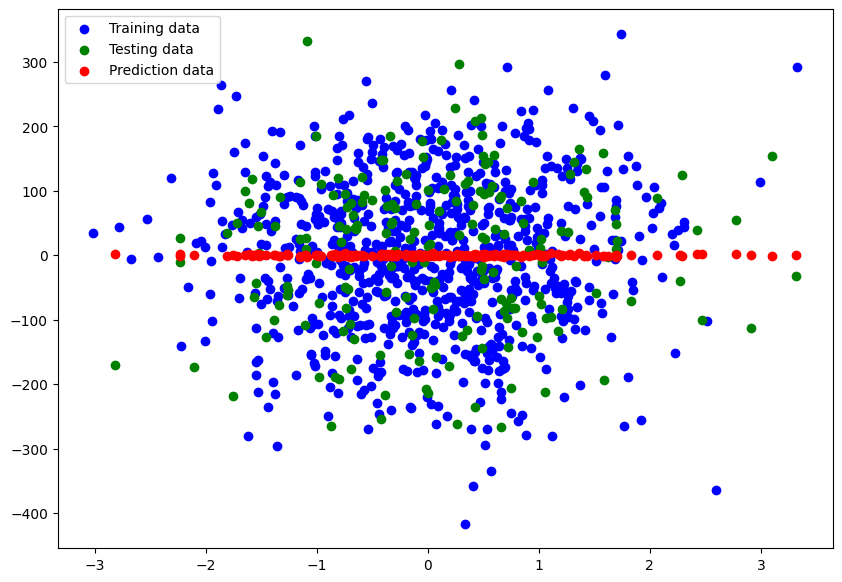

In [124]:
# Plotting our predictions with our target
plot_prediction(
    train_data=X_train[:, 0], 
    train_labels=y_train, 
    test_data=X_test[:, 0], 
    test_labels=y_test, 
    predictions=y_preds_1
)

Great! Our model is trying to preict the points but it's not doing a great job with it.

Let's try couple of experiments

In [125]:
# Building a model with 2 layers and fewer units
tf.random.set_seed(42)

# Build the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(10)
])

# Compile the model
model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics='mae'
)

# Fit the model
model_2.fit(X_train, y_train, epochs=100)

Epoch 1/100
25/25 [==============================] - 0s 667us/step - loss: 94.6293 - mae: 94.6293
Epoch 2/100
25/25 [==============================] - 0s 713us/step - loss: 94.5325 - mae: 94.5325
Epoch 3/100
25/25 [==============================] - 0s 709us/step - loss: 94.4177 - mae: 94.4177
Epoch 4/100
25/25 [==============================] - 0s 625us/step - loss: 94.2745 - mae: 94.2745
Epoch 5/100
25/25 [==============================] - 0s 583us/step - loss: 94.1016 - mae: 94.1016
Epoch 6/100
25/25 [==============================] - 0s 708us/step - loss: 93.8882 - mae: 93.8882
Epoch 7/100
25/25 [==============================] - 0s 592us/step - loss: 93.6375 - mae: 93.6375
Epoch 8/100
25/25 [==============================] - 0s 667us/step - loss: 93.3416 - mae: 93.3416
Epoch 9/100
25/25 [==============================] - 0s 667us/step - loss: 93.0034 - mae: 93.0034
Epoch 10/100
25/25 [==============================] - 0s 625us/step - loss: 92.6121 - mae: 92.6121
Epoch 11/100
25/25 

In [126]:
# Building our model with 3 layers and with more hidden units 

tf.random.set_seed(42)

# Creating the model 
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(50), 
  tf.keras.layers.Dense(1) # Should be always one 
])

# Compile the model 
model_3.compile(loss = tf.keras.losses.mae , 
                optimizer = tf.keras.optimizers.Adam() , 
                metrics = ['mae'])

# Fit the model 
model_3.fit(X_train , y_train , epochs = 100)

Epoch 1/100
25/25 [==============================] - 0s 667us/step - loss: 94.0780 - mae: 94.0780
Epoch 2/100
25/25 [==============================] - 0s 667us/step - loss: 91.4911 - mae: 91.4911
Epoch 3/100
25/25 [==============================] - 0s 709us/step - loss: 85.1836 - mae: 85.1836
Epoch 4/100
25/25 [==============================] - 0s 688us/step - loss: 70.9880 - mae: 70.9880
Epoch 5/100
25/25 [==============================] - 0s 708us/step - loss: 45.4666 - mae: 45.4666
Epoch 6/100
25/25 [==============================] - 0s 792us/step - loss: 18.7504 - mae: 18.7504
Epoch 7/100
25/25 [==============================] - 0s 1ms/step - loss: 4.1417 - mae: 4.1417
Epoch 8/100
25/25 [==============================] - 0s 752us/step - loss: 1.3049 - mae: 1.3049
Epoch 9/100
25/25 [==============================] - 0s 709us/step - loss: 0.7278 - mae: 0.7278
Epoch 10/100
25/25 [==============================] - 0s 668us/step - loss: 0.3956 - mae: 0.3956
Epoch 11/100
25/25 [=========

Wooo! Look at that, but we shouldn't be excited lets evaluate

In [127]:
model_3.evaluate(X_test, y_test)

7/7 [==============================] - 0s 833us/step - loss: 0.1852 - mae: 0.1852


[0.18522071838378906, 0.18522071838378906]

In [129]:
# Making predictions
y_preds_3 = model_3.predict(X_test)
y_preds_3.shape

7/7 [==============================] - 0s 666us/step


(200, 1)

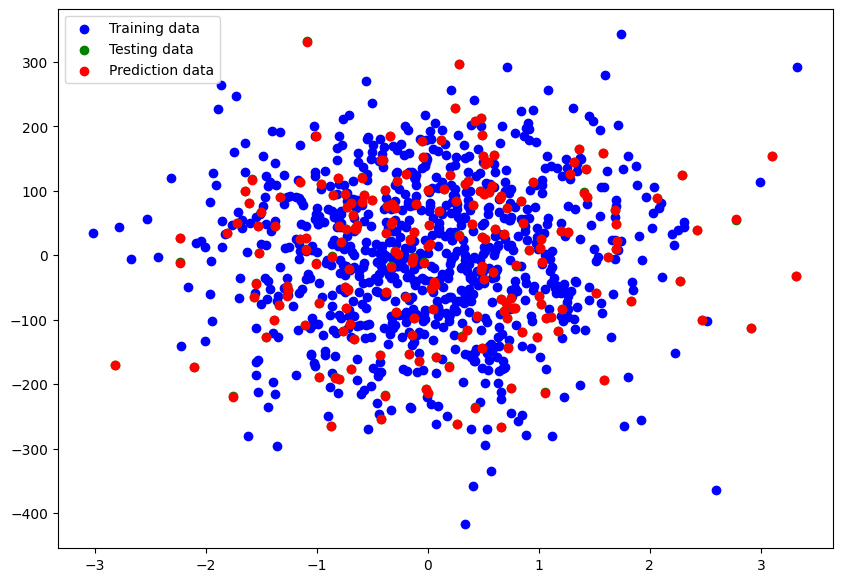

In [131]:
plot_prediction(X_train[: , 0] , y_train , 
                 X_test[: , 0] , y_test , 
                 y_preds_3)

Look at that! Our model has predicted every test data correctly. You can't spot a green dot (test data) it's because our prediction (ret dot) overlapped

Our model is doing a perfect job

### Try and improve the results we got on the insurance dataset, some thisn you might want to try include:

* Building a larger model (how does one with 4 Dense layers go?)
* Increasing the number of units in each layer.
Look up the documentation of Adam and find out what the first paratemer is, what happen if you increase it by 10x?
* What happens if you train for longer (say 300 epoch instead of 200)

#### Building a larger model (how does one with 4 dense layers go?)

In [132]:
# Let's download the data 
import pandas as pd 
import numpy as np 

data = pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv')

data.shape

(1338, 7)

Our insurance data hase 1338 rows and 7 columns

In [133]:
# Looking into the data
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


We have same categorical variable, let's conver those columns into numerical used pandas.

In [143]:
# Turn categorical into numbers
data_one_hot = pd.get_dummies(data, dtype=int)
data_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1,0,0,1,0,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0,0,0,1,0
2,28,33.000,3,4449.46200,0,1,1,0,0,0,1,0
3,33,22.705,0,21984.47061,0,1,1,0,0,1,0,0
4,32,28.880,0,3866.85520,0,1,1,0,0,1,0,0


In [144]:
# Splitting into X and y
X = data_one_hot.drop('charges', axis=1)
y = data_one_hot['charges']

X.shape, y.shape

((1338, 11), (1338,))

In [145]:
# Creating train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Checking the shapes
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1070, 11), (1070,), (268, 11), (268,))

In [146]:
# Building the model with 4 dense layers and more units

tf.random.set_seed(42)

# Create the model 
model = tf.keras.Sequential([
  tf.keras.layers.Dense(300) , 
  tf.keras.layers.Dense(200), 
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(50) ,
  tf.keras.layers.Dense(1)
])


# Compiling the model 
model.compile(loss = tf.keras.losses.mae , 
              optimizer = tf.keras.optimizers.Adam() , 
              metrics = ['mae'])

# Fit the model 
model.fit(X_train , y_train , epochs = 100)

Epoch 1/100
34/34 [==============================] - 0s 971us/step - loss: 10877.5098 - mae: 10877.5098
Epoch 2/100
34/34 [==============================] - 0s 923us/step - loss: 7439.8940 - mae: 7439.8940
Epoch 3/100
34/34 [==============================] - 0s 909us/step - loss: 7074.5684 - mae: 7074.5684
Epoch 4/100
34/34 [==============================] - 0s 1ms/step - loss: 6819.2349 - mae: 6819.2349
Epoch 5/100
34/34 [==============================] - 0s 1ms/step - loss: 6671.3208 - mae: 6671.3208
Epoch 6/100
34/34 [==============================] - 0s 909us/step - loss: 6581.9561 - mae: 6581.9561
Epoch 7/100
34/34 [==============================] - 0s 911us/step - loss: 6517.4404 - mae: 6517.4404
Epoch 8/100
34/34 [==============================] - 0s 970us/step - loss: 6461.2021 - mae: 6461.2021
Epoch 9/100
34/34 [==============================] - 0s 898us/step - loss: 6355.9512 - mae: 6355.9512
Epoch 10/100
34/34 [==============================] - 0s 925us/step - loss: 6243.116

### Lookup the documentation of Adam and find out what the first parameter is,what happens if you increase it by 10x?

And running for 400 epochs

In [147]:
# Let's tweak the Adam Optimizer's learning rate 

tf.random.set_seed(42)

# Create the model 
model = tf.keras.Sequential([
  tf.keras.layers.Dense(100) , 
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])


# Compiling the model 
model.compile(loss = tf.keras.losses.mae , 
              optimizer = tf.keras.optimizers.Adam(learning_rate= 0.001*10 ) , 
              metrics = ['mae'])

# Fit the model 
history = model.fit(X_train , y_train , epochs = 400)

Epoch 1/400
34/34 [==============================] - 0s 727us/step - loss: 8653.3877 - mae: 8653.3877
Epoch 2/400
34/34 [==============================] - 0s 1ms/step - loss: 6943.8472 - mae: 6943.8472
Epoch 3/400
34/34 [==============================] - 0s 1ms/step - loss: 6226.2627 - mae: 6226.2627
Epoch 4/400
34/34 [==============================] - 0s 1ms/step - loss: 5404.8516 - mae: 5404.8516
Epoch 5/400
34/34 [==============================] - 0s 939us/step - loss: 4168.5259 - mae: 4168.5259
Epoch 6/400
34/34 [==============================] - 0s 848us/step - loss: 3949.0122 - mae: 3949.0122
Epoch 7/400
34/34 [==============================] - 0s 876us/step - loss: 4075.4187 - mae: 4075.4187
Epoch 8/400
34/34 [==============================] - 0s 879us/step - loss: 4192.6831 - mae: 4192.6831
Epoch 9/400
34/34 [==============================] - 0s 848us/step - loss: 3899.0137 - mae: 3899.0137
Epoch 10/400
34/34 [==============================] - 0s 892us/step - loss: 3857.9194 - 

In [148]:
# Evaluate on test data 
model.evaluate(X_test , y_test)

9/9 [==============================] - 0s 750us/step - loss: 3232.8179 - mae: 3232.8179


[3232.81787109375, 3232.81787109375]

Text(0.5, 0, 'Epochs')

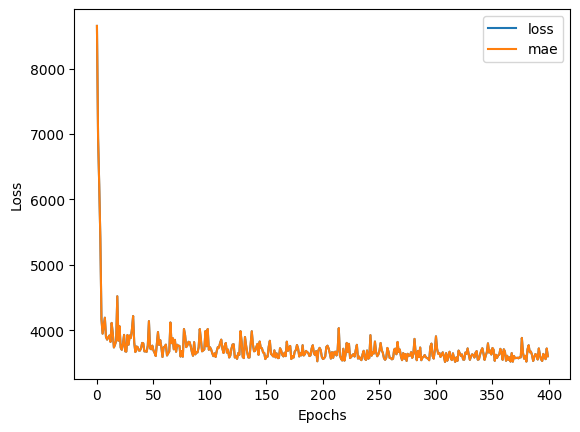

In [149]:
# Let's plot the loss curve Vs Epochs 
pd.DataFrame(history.history).plot()
plt.ylabel('Loss')
plt.xlabel('Epochs')

Seems even increasing the learning rate and the number of epochs the model isn't performing an greater level. 

## Import the Boston pricing dataset from TensorFlow `tf.keras.datasets` and model it

In [106]:
# getting the boston dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.boston_housing.load_data(path= 'boston_housing_npz', test_split=0.2, seed=43)

In [107]:
# Checkin the shape of our data
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((404, 13), (102, 13), (404,), (102,))

This dataset is numpy array format and it's normalized

In [108]:
# Let's build a model
tf.random.set_seed(42)

# Building a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(200),
    tf.keras.layers.Dense(200),
    tf.keras.layers.Dense(150),
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(1),
])

# Compile the model
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics='mae'
)

# Fit the model
history = model.fit(X_train, y_train, epochs=300)

Epoch 1/300
13/13 [==============================] - 0s 1ms/step - loss: 80.2577 - mae: 80.2577
Epoch 2/300
13/13 [==============================] - 0s 2ms/step - loss: 18.7835 - mae: 18.7835
Epoch 3/300
13/13 [==============================] - 0s 2ms/step - loss: 11.2320 - mae: 11.2320
Epoch 4/300
13/13 [==============================] - 0s 1ms/step - loss: 6.7957 - mae: 6.7957
Epoch 5/300
13/13 [==============================] - 0s 1000us/step - loss: 5.8685 - mae: 5.8685
Epoch 6/300
13/13 [==============================] - 0s 1000us/step - loss: 6.4771 - mae: 6.4771
Epoch 7/300
13/13 [==============================] - 0s 916us/step - loss: 6.3150 - mae: 6.3150
Epoch 8/300
13/13 [==============================] - 0s 833us/step - loss: 6.8516 - mae: 6.8516
Epoch 9/300
13/13 [==============================] - 0s 1ms/step - loss: 6.0386 - mae: 6.0386
Epoch 10/300
13/13 [==============================] - 0s 955us/step - loss: 6.1040 - mae: 6.1040
Epoch 11/300
13/13 [=====================

In [109]:
# Let's evaluate on the test data
model.evaluate(X_test, y_test)

4/4 [==============================] - 0s 1ms/step - loss: 3.8725 - mae: 3.8725


[3.8725006580352783, 3.8725006580352783]

Text(0.5, 0, 'epochs')

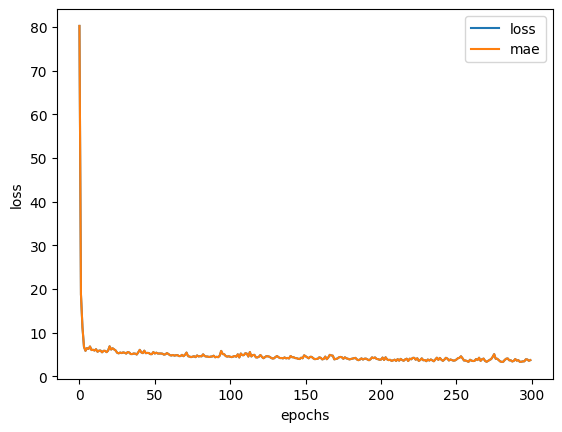

In [110]:
# Plotting the Loss vs Epoch
pd.DataFrame(history.history).plot()
plt.ylabel('loss')
plt.xlabel('epochs')